# Structural color 

***

The `color_system` module of tostada can map scattering features of a point- or phase-distribution to its visual color appearance. This is possible in two ways:

1) Describing Structure-factor/Spectral Density as a function of scattering angle $\theta$ and wavelength $\lambda$ and mapping it to tristimulus values $(X,Y,Z)$.

2) Determining scattered light from an optical simulation/experiment as a function of scattering angle $\theta$ and wavelength $\lambda$ and mapping it to tristimulus values $(X,Y,Z)$.

For standard illumination options, these chromaticity coordinates are then mapped to R,G,B values after a gamma-correction to give the true visual appearance from the system.

The conversion of a reflectance spectra to $(X,Y,Z)$ is given by:

$ X = \int x(\lambda)R(\lambda) I(\lambda) d\lambda $

$ Y = \int y(\lambda)R(\lambda) I(\lambda) d\lambda $

$ Z = \int z(\lambda)R(\lambda) I(\lambda) d\lambda $

where $x(\lambda)$, $y(\lambda)$ and $z(\lambda)$ are the CIE standard observer functions, $I(\lambda)$ is the illumination and $R(\lambda)$ is the reflectance.

In [1]:
import numpy as np
import tostada as tost
import matplotlib.pyplot as plt

Let us define an artificial spectrum $R(\lambda)$ that a gaussian centered around a central wavelength $\lambda_0=0.55\mu m$. We wish to quantify the visual appearance of an artificial scattering system with such a spectrum.

Text(0, 0.5, 'Reflectance')

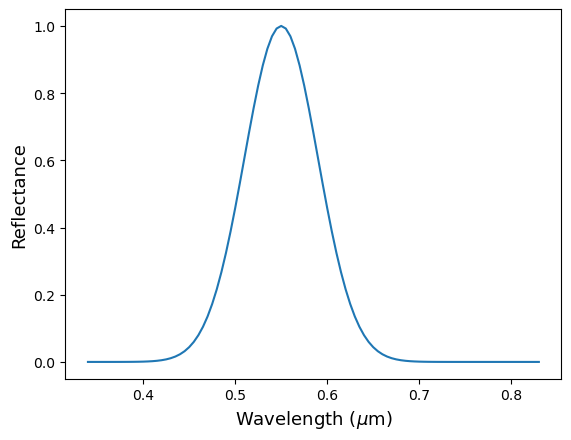

In [3]:
wvl = np.arange(340,835,5)/1e3
wvl0 = 550/1e3

R = np.exp(-(wvl-wvl0)**2/(2*(0.04)**2))
plt.plot(wvl,R)
plt.xlabel('Wavelength ($\mu$m)',fontsize=13)
plt.ylabel('Reflectance',fontsize=13)

This spectra can now be mapped to $(X,Y,Z)$. But, mapping this to R,G,B values requires comparing these to a reference white color. This reference is different for each R,G,B working space. Currently, there are only three available color spaces : 1) sRGB 2) SMPTE-C RGB and 3) HDTV.

Without getting into much detail here, we use the sRGB color space available in `tostada.color_system` as `cs_srgb`.

In [4]:
from tostada.color_system import cs_srgb
RGB = cs_srgb.spec_to_rgb(np.c_[wvl,R]) # converts spectrum to R,G,B values. Gamma correction can be turned off with `gamma_correction=False`
print (RGB)

[0.61371158 0.93948838 0.        ]


The RGB values here can be visualized using `tostada.plot_util` using `plot_colors()` static method (available without creating the `Visualize` object).

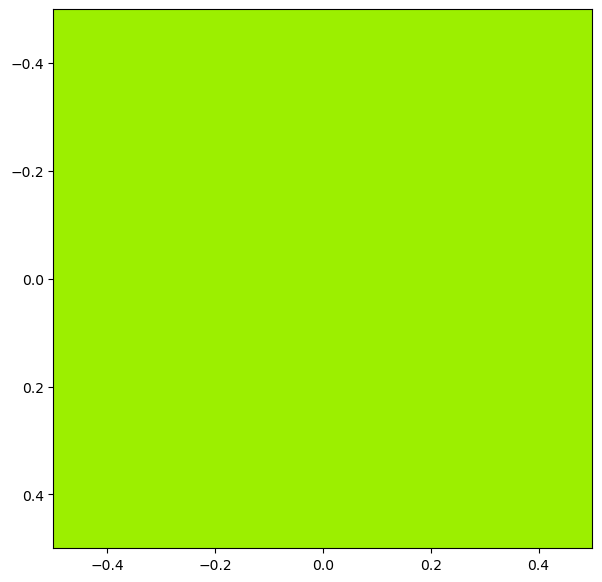

In [171]:
tost.Visualize.plot_colors(RGB)

Our spectra yields a predictable green color that is not surprising since the spectrum was centered around the wavelength where green contribution is dominant. This can be understood by plotting the CIE standard observer function $y(\lambda)$ that is responsible for dominant green contribution.

Text(0.5, 0, 'Wavelength ($\\mu$m)')

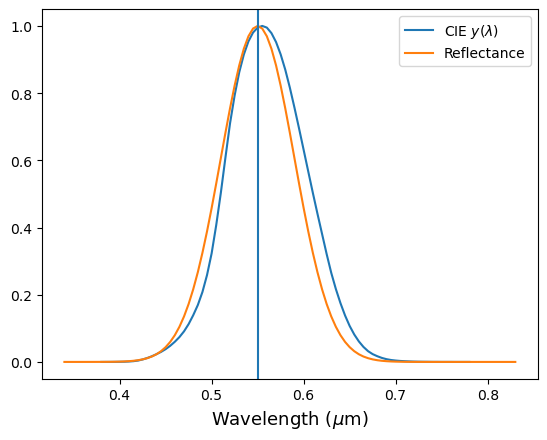

In [33]:
plt.plot(cs_srgb.cmf[:,0]/1e3,cs_srgb.cmf[:,2],label='CIE $y(\lambda)$')
plt.plot(wvl,R,label='Reflectance')
plt.legend()
plt.axvline(x=wvl0)
plt.xlabel('Wavelength ($\mu$m)',fontsize=13)


Since color perception is subjective, the evaluations of XYZ and RGB values in `tostada` are done in reference with CIE measurements with standard color spaces, illumination and $2\degree$ observer. CIE then gives a reference spectra for benchmarking. For future develop in the `color_system` module, this is made available in the `tostada.util` folder. 

In [34]:
from importlib.resources import files

with files('tostada.util').joinpath('cie_ref_spec.csv').open('r') as f:
    cie= np.loadtxt(f)

In [ ]:
cs = cs_srgb.spec_to_rgb(spec=np.c_[cie[:,0]/1e3,cie[:,1]]) #R,G,B
cs

array([0.48637221, 0.30578302, 0.24090822])

#### For the same conditions, CIE gives gamma-corrected R,G,B values as *$(0.45, 0.31, 0.25)$*. This is in good agreement with our results given different integration methods and wavelength spacing.

The color perception above is for a fixed angle of scattering. `tostada.color_system` can be used collectively for a set of angles too, basically the angular spectrum. Since each scattering angle can be mapped to reciprocal-space wave-vector, the reciprocal-space response (proportional to Structure factor of Spectral density) can also be used to obtain color diffraction images.

First, let us create a point distribution.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[<Axes: title={'center': 'Reciprocal Space, Structure Factor $S(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mu$m$^{-1}$)', ylabel='$q_{y}$ ($\\mu$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mu$m$^{-1}$)', ylabel='$\\tilde{S}(|\\mathbf{q}|)$'>]

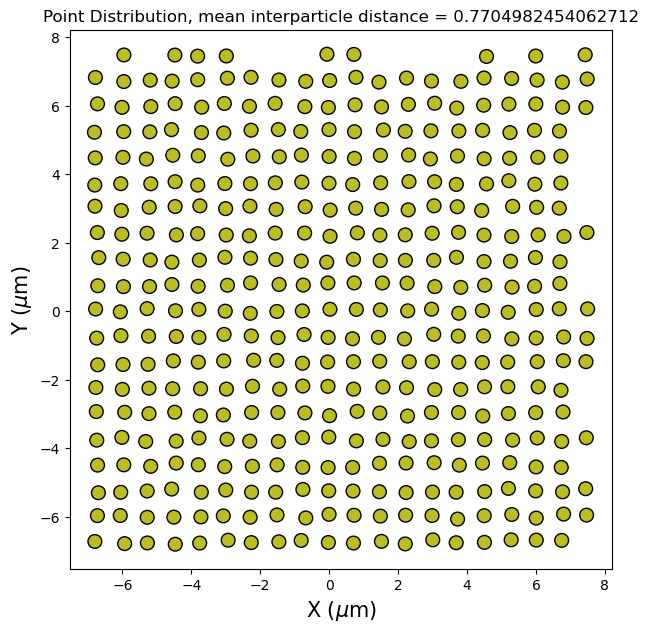

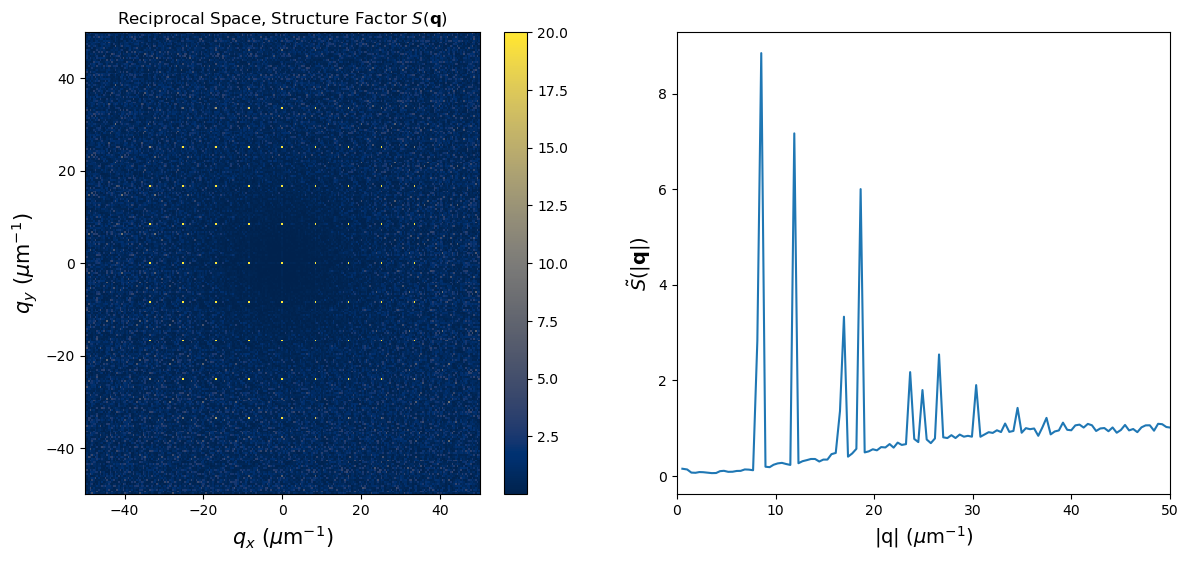

In [5]:
process = tost.Pointprocess(20*0.75,0.4,0.75)
points = process.rect_lattice(noise=0.2)

fig = tost.Visualize(points)
fig.plot_distribution()
fig.plot_reciprocal_space(kmax=50)

Since $S(q)$ is evaluated for fixed set of $q_i$ obtained from spatial frequencies of the simulation box, the structure factor would currently be un-defined for wave-vectors obtained using $2\pi/\lambda$. Therefore, the structure-factor must be interpolated at each wavelengths (frequencies). This is done in `tostada.util.Utility.Spectra` module directly available via `tost.Spectrum()`.

In [6]:
sp = tost.Spectrum(wavelength = wvl, 
                   spectra = None, 
                   distribution=points)

Now, the angular spectrum $I(\theta,\phi,\lambda)$ or $I(q_x,q_y,\lambda)$ can be evaluated using `Angular_spectrum()` method. Note, there is also an additional functionality of specifying form-factor (scattering from an individual particle) such that the $I = S(q)f(q)$.

In [7]:
I2d,I1d = sp.Angular_spectrum()

This gives two quantities, one is the 2D scattering as a function of polar angle wavelength and other is it's angular-average.

In [ ]:
print(I2d.shape) # axis=0 => wavelength, axis=1,2 => theta,phi
print (I1d.shape) # axis=0 => wavelength, axis=1 => theta

(99, 200, 200)
(99, 100)


The angular-averaged $I(\theta,\lambda)$ can be best visualized in a polar plot available in the `plot_util` module as `plot_polar`. Note: this is also a static method and the whole `Visualize` class need not be instanced.

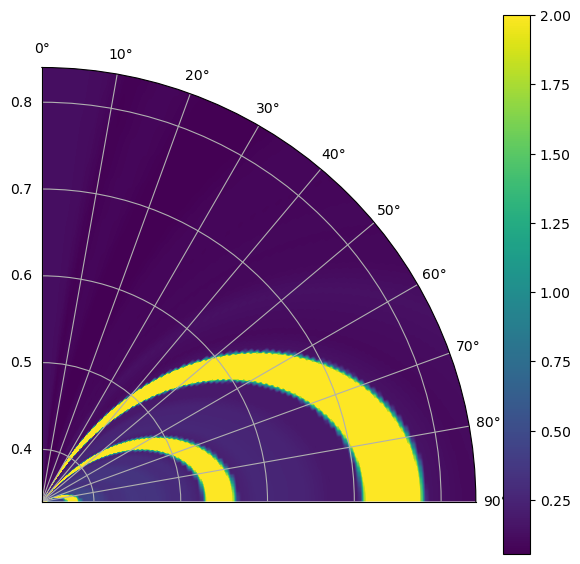

In [29]:
tost.Visualize.plot_polar(I1d,0.34,0.84)

#### The polar plot here can be understood by the realising that scattering in a periodic lattice is suppressed for $q\rightarrow 0$ which corresponds to suppressed scattering close to (but not equal to) normal incidence. 

***

#### The 2D scattering response for each wavelength $I(\theta,\phi,\lambda)$ can be used to extract R,G,B values using `colorize_spectra()` available in `color_systems` and later visualized in $RGB(\theta,\phi)$ using the same `Visualize.plot_colors()` method as before.

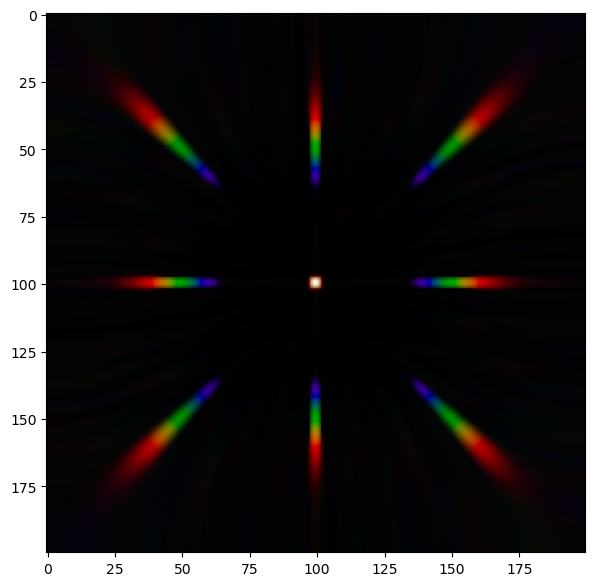

In [16]:
cs = cs_srgb.colorize_spectra(sp.wavelength,I2d,gamma_correction=True)
fig = tost.Visualize.plot_colors(cs)

#### The exact same methods are equally applicable for angular-averaged dataset obtained from `Angular_spectrum()`.

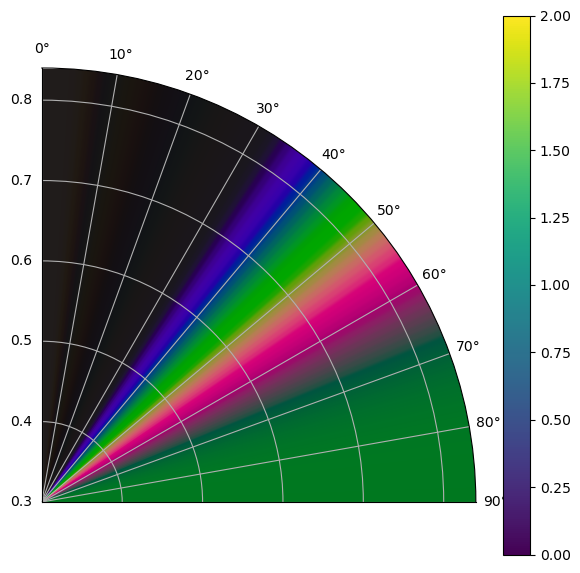

In [58]:
cs_ = cs_srgb.colorize_spectra(wvl,I1d)
tost.Visualize.plot_polar(cs_,wvl_0=0.3,wvl_f=0.84)